In [13]:
%%time
#the purpose of this cell is to read 3I_sub.txt, line by line, and then save all of the observations before febuary 19, 2026 to a new, seperate file
keep = [] #creates an empty list, will collect every line we decide to save
with open("../data/3I_sub.txt", encoding="utf-8-sig") as f: #opens my file for reading, calls it f
    for line in f:
        if "2025 05 15" <= line [15:25] <= "2026 02 19": #if between desired dates
            keep.append(line)
with open("../data/3I_sub_to_2026-02-19.txt", "w") as f: #opens new file
    f.writelines(keep) #adds keep to new file
print(len(keep)) #prints length of new file
print(keep[0][:32]) #prints the time of the first line, should be the TESS observation from may
print(keep[1][:32]) #prints the time of line 2
print(keep[-1][:32]) #prints the time of the last line, should be either on the 19th, or before then.

809
0003I         S2025 05 31.233670
0003I         s2025 05 31.233670
0003I        KC2026 02 19.980266
CPU times: user 305 μs, sys: 1.77 ms, total: 2.07 ms
Wall time: 1.96 ms


In [14]:
#this cell loads the needed tools for my graphing
import re #regular expressions
from pathlib import Path #tool for file locations
import pandas as pd #table library
import matplotlib.pyplot as plt #loads the plotting library
from matplotlib.ticker import StrMethodFormatter # tool for how axis numbers are written


In [15]:
#this cell holds all of JPL's Values
JPL = {
    "1I": { #'Oumuamua, JPL solution 16
        "epoch": 2458080.5,
        "e":    (1.201133796102373,    2.1064e-5),
        "q":    (0.2559115812959116,   6.6635e-6),
        "i":    (122.7417062847286,    2.8826e-4),
        "node": (24.59690955523242,    2.5422e-4),
        "peri": (241.8105360304898,    1.2495e-3),
        "Tp":   (2458006.007321375231, 2.6424e-4),
    },
    "2I": { #Borisov, JPL solution 54
        "epoch": 2458853.5,
        "e":    (3.356475782677,       1.9039e-5),
        "q":    (2.006520878501,       3.2904e-6),
        "i":    (44.05264247909,       1.6673e-5),
        "node": (308.1477292270,       4.5021e-5),
        "peri": (209.1236864378,       1.1012e-4),
        "Tp":   (2458826.052845906,    1.4206e-4),
    },
    "3I": { #ATLAS, JPL solution 54
        "epoch": 2461090.5,
        "e":    (6.141351449317625,    2.469e-5),
        "q":    (1.356481057231181,    3.7743e-6),
        "i":    (175.1164570850441,    1.9023e-5),
        "node": (322.1696089290778,    7.0591e-5),
        "peri": (128.0228697185194,    1.0119e-4),
        "Tp":   (2460977.995262847653, 5.0807e-5),
    }
}
ELEMENTS = ["e", "q", "i", "node", "peri", "Tp"] #holds the six element names in plot order, so its always gone through in the same order in later steps.

In [16]:
#this cell will create a functhin that reads the findorb file, and pulls out the needed orbital elements, and then runs the function on the 1I orbit fit
def read_findorb(path):
    text = Path(path).read_text()
    patterns = { #dictonary that pairs each elemtn name with the search pattern to find its number
        #r"..." = backslashes pass to pattern tool
        #\s+ = one or more spaces
        #([\d.]+) = one more digits \d. Parentheses mark it as what to grab
        #\. = a real dot, means any character
        #^ = the start of a line
        #\$ = a real dollar sign
        "epoch": r"JDT ([\d.]+)",
        "e": r"^e\s+([\d.]+)",
        "q": r"^q\s+([\d.]+)",
        "i": r"Incl\.\s+([\d.]+)",
        "node": r"Node\s+([\d.]+)",
        "peri": r"Peri\.\s+([\d.]+)",
        "Tp": r"\$T=([\d.]+)",
    }
    values = {} #empty dict to collect found numbers
    for name, pattern in patterns.items(): #loops through each name one at a time
        match = re.search(pattern, text, re.MULTILINE) #finds the first place the pattern appears. re.MULTILINE turns ^ into meaning the start of ANY line, not just the start of the whole file
        if match is None: #if nothing found, code stops, says what it can't find
            raise ValueError(f"Couldn't find {name} in {path}")
        values[name] = float(match.group(1)) #takes grabbed values, and thrns them into numbers
    return values #hands dict back

read_findorb("../results/1I_findorb_2026-09-27_grav.txt") #tests on the 1I orbit fit from today.


{'epoch': 2458080.5,
 'e': 1.2008786,
 'q': 0.25583524,
 'i': 122.73437,
 'node': 24.59721,
 'peri': 241.7945,
 'Tp': 2458006.002874}

In [17]:
#this code will determine the difference between each value that will be in the end graph, and then compiles them into a table.
rows = []
for obj in ["1I", "2I", "3I"]: #loops over the three objects 
    path = f"../results/{obj}_findorb_2026-09-27_grav.txt" #builds the file name, {obj} tets swapped in
    mine = read_findorb(path) #uses the above cell's function to read my numbers from the current file of focus
    if mine["epoch"] != JPL[obj]["epoch"]: #checks whether the epoch is the same
        raise ValueError(f"{obj}: my epoch {mine['epoch']} isn't JPL's {JPL[obj]['epoch']}") #stops witha  message showing the two epochs, if they don't match
    for el in ELEMENTS: #a loop, goes through each element (for the current object)
        jpl_value, jpl_sigma = JPL[obj][el] #looks up JPL's value pair from the library above, and splits it into two named variables
        offset = abs(mine[el] - jpl_value) / jpl_sigma #this is the formula that finds how far apart my two numbers are
        rows.append({"object": obj, "element": el, "mine": mine[el], "jpl": jpl_value, "jpl_sigma": jpl_sigma, "offset_sigma": offset}) #adds a row to the list. each row holds the object, the element, both my and JPL's value, what JPL's sigma value actually is, and the end difference

table = pd.DataFrame(rows) # turns the list into a pandas table
table.pivot(index = "element", columns="object", values="offset_sigma").loc[ELEMENTS].round(1) #reshapes the table, amkes it easy to read. Puts the elements down the side and objects accross the top, keeps elements in the pre-chosen order, and only shows one decimal place.

object,1I,2I,3I
element,,,
e,12.1,11.1,10.3
q,11.5,14.7,21.4
i,25.5,12.1,35.1
node,1.2,8.5,23.2
peri,12.8,1.3,1.3
Tp,16.8,0.1,5.8


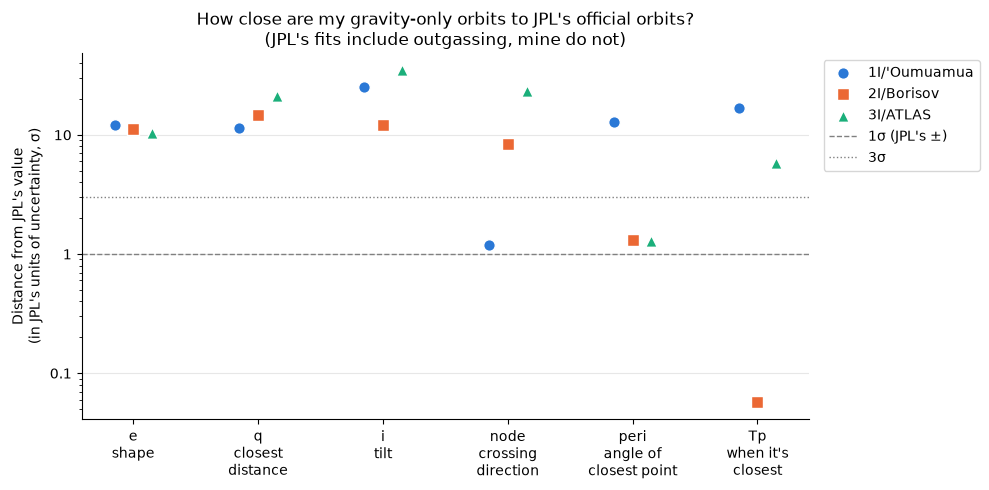

CPU times: user 645 ms, sys: 66.5 ms, total: 711 ms
Wall time: 1.25 s


In [18]:
%%time
#this cell will put all 18 offsets onto on one chart
LABELS = { #a dictionary that pairs each element with the label printed unerneath it. \n means new line.
    "e": "e\nshape",
    "q": "q\nclosest\ndistance",
    "i": "i\ntilt",
    "node": "node\ncrossing\ndirection",
    "peri": "peri\nangle of\nclosest point",
    "Tp": "Tp\nwhen it's\nclosest",
}
STYLE = { #pairs each ISO with the color, marker shape, and the name for the legend
    "1I": ("#2a78d6", "o", "1I/'Oumuamua"),
    "2I": ("#eb6834", "s", "2I/Borisov"),
    "3I": ("#1baf7a", "^", "3I/ATLAS")
}
SHIFT = {"1I": -0.15, "2I": 0.0, "3I": 0.15} #shifts each object's markers so they don't overlap

fig, ax = plt.subplots(figsize=(10, 5)) #makes a blank image, with a plotting area

for obj, (color, marker, name) in STYLE.items(): #loops over the objects and unpacks its style settings
    part = table[table["object"] == obj] #keeps only this object's 6 rows from the table
    x = [ELEMENTS.index(el) + SHIFT[obj] for el in part ["element"]] #works out each marker's left-right position
    ax.scatter(x, part["offset_sigma"], color=color, marker=marker, s=70, edgecolor="white", linewidth=1, label=name, zorder=3) #draws the markers

#the below lines are the "reference lines"
ax.axhline(1, color="gray", linestyle="--", linewidth=1, label="1σ (JPL's ±)") #draws a dashed horozontal line across the chart, at 1σ
ax.axhline(3, color="gray", linestyle=":", linewidth=1, label="3σ") #draws a dotted line at 3σ

ax.set_yscale("log") #switches the y-axis to a logramithic scale
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:g}")) #writes the y-axis numbers in plain form. gives 0.1, 1, 10 instead of 10^-1
ax.set_xticks(range(len(ELEMENTS))) #puts tick marks at positions 0 through 5. len counts the items in the list
ax.set_xticklabels([LABELS[el] for el in ELEMENTS]) #writes each element's label at its tick
ax.set_ylabel("Distance from JPL's value\n(in JPL's units of uncertainty, σ)") #axis label
ax.set_title("How close are my gravity-only orbits to JPL's official orbits?\n""(JPL's fits include outgassing, mine do not)") #title
ax.grid(axis="y", alpha=0.3) #adds faint horizontal gridlines
ax.spines[["top", "right"]].set_visible(False) #removes the top and right border lines
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1)) #places the key, outside of edge of chart

fig.tight_layout() #adjusts spacing so no labels get cut
fig.savefig("../figures/orbit_accuracy_v2.png", dpi=200) #saves the picture in figures folder
plt.show()#shows the chart in the notebook